In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_excel(r"C:\Users\ASUS\Desktop\3y\S2\machine learning\Project\Local\Data\brahimi_original.xlsx")
print(df.head())

             name  location_lat  location_lng
0  Amphitheater 5     36.688273      2.866739
1  Amphitheater 6     36.688397      2.866484
2  Amphitheater 6     36.688326      2.866466
3  Amphitheater 6     36.688379      2.866405
4  Amphitheater 6     36.688317      2.866468


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          294 non-null    object 
 1   location_lat  294 non-null    float64
 2   location_lng  294 non-null    float64
dtypes: float64(2), object(1)
memory usage: 7.0+ KB


In [8]:
amphi_corners = {
    "Amphi 5": [
        (36.6882320, 2.8666535),  # top-left
        (36.6882443, 2.8668060),  # top-right
        (36.6880865, 2.8668389),  # bottom-right
        (36.6880720, 2.8666538),  # bottom-left
    ],
    "Amphi 6": [
        (36.6882129, 2.8663997),  # top-left
        (36.6882193, 2.8665428),  # top-right
        (36.6880268, 2.8665894),  # bottom-right
        (36.6880123, 2.8663926),  # bottom-left
    ],
}

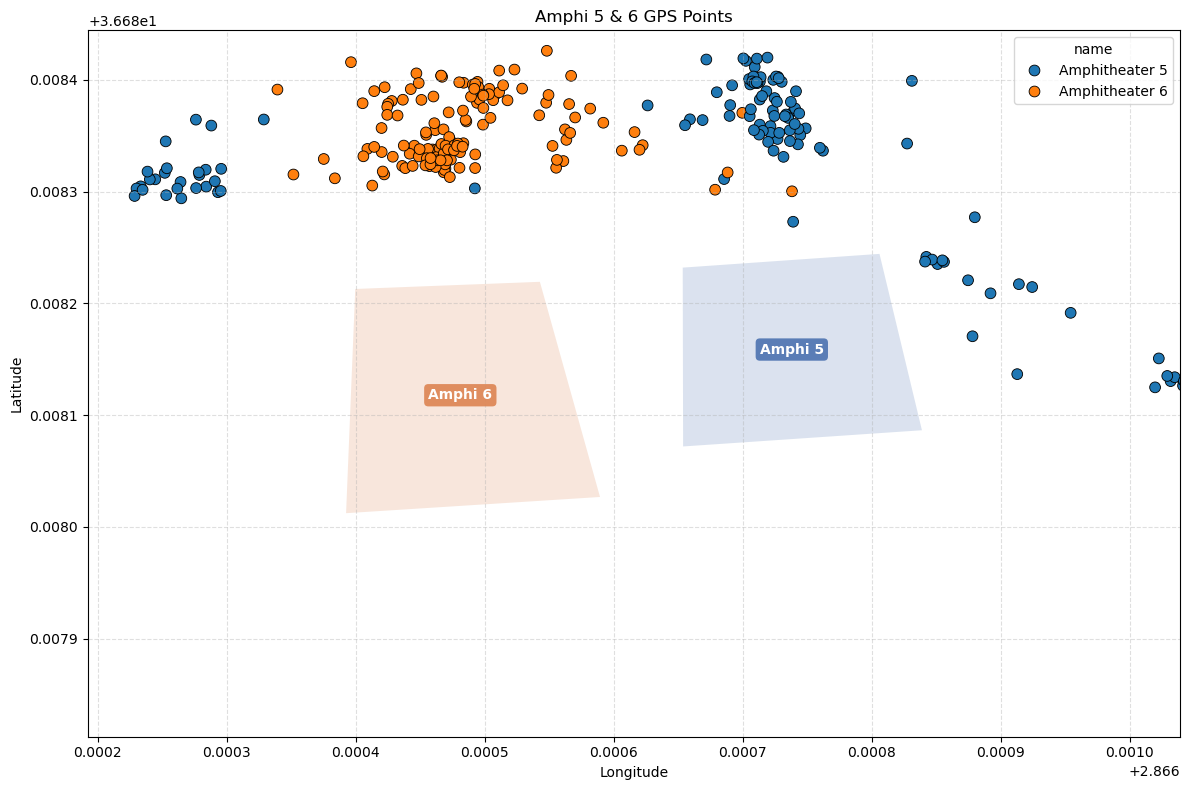

In [10]:

from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

colors = ['#4C72B0', '#DD8452']
amphi_names = list(amphi_corners.keys())

fig, ax = plt.subplots(figsize=(12, 8))

# 1. Plot polygons
patches = []
for (name, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    poly = Polygon(xy, closed=True)
    patches.append(poly)

    # center label
    cx, cy = xy[:, 0].mean(), xy[:, 1].mean()
    ax.text(cx, cy, name, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.3', fc=color, ec='none', alpha=0.9))

collection = PatchCollection(patches, facecolors=colors, alpha=0.2)
ax.add_collection(collection)

# 2. Scatter points (your data)
sns.scatterplot(
    data=df,
    x='location_lng',
    y='location_lat',
    hue='name',   # differentiate Amphi 5 vs 6
    s=60,
    edgecolor='black',
    ax=ax
)

# Formatting
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Amphi 5 & 6 GPS Points')

ax.grid(True, linestyle='--', alpha=0.4)

# auto limits
all_lats = [c[0] for corners in amphi_corners.values() for c in corners]
all_lons = [c[1] for corners in amphi_corners.values() for c in corners]

ax.set_xlim(min(all_lons) - 0.0002, max(all_lons) + 0.0002)
ax.set_ylim(min(all_lats) - 0.0002, max(all_lats) + 0.0002)

plt.tight_layout()
plt.show()

In [11]:
df['label'] = df['name'].str.extract(r'(\d+)').astype(int)  # extract 5 or 6

In [13]:
X = df[['location_lat', 'location_lng']]
y = df['label']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [16]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.559322033898305
              precision    recall  f1-score   support

           5       0.00      0.00      0.00        26
           6       0.56      1.00      0.72        33

    accuracy                           0.56        59
   macro avg       0.28      0.50      0.36        59
weighted avg       0.31      0.56      0.40        59



c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


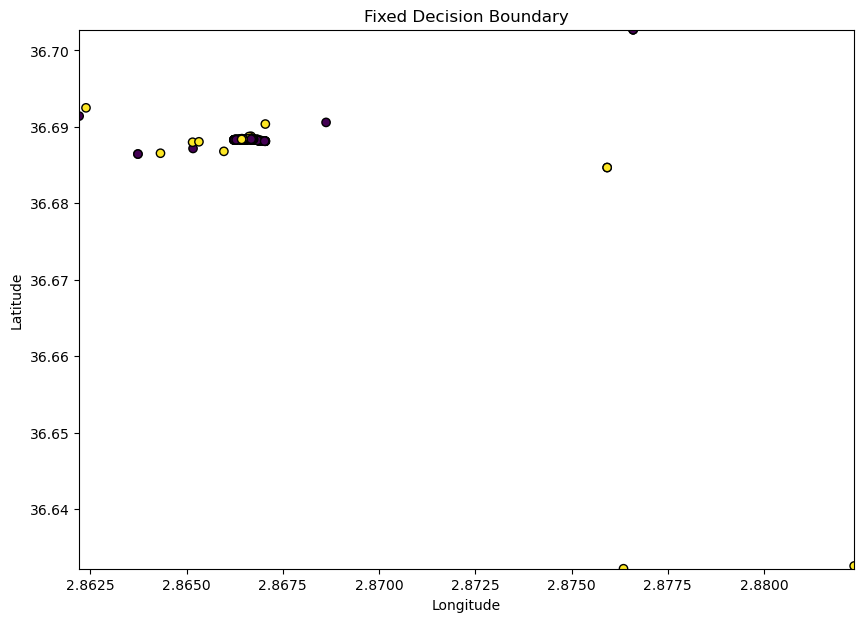

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Define bounds correctly
lat_min, lat_max = X['location_lat'].min(), X['location_lat'].max()
lng_min, lng_max = X['location_lng'].min(), X['location_lng'].max()

# IMPORTANT: meshgrid should be (lng, lat) for plotting
xx, yy = np.meshgrid(
    np.linspace(lng_min, lng_max, 300),   # x → longitude
    np.linspace(lat_min, lat_max, 300)    # y → latitude
)

# BUT model expects (lat, lng)
grid_points = pd.DataFrame(np.c_[yy.ravel(), xx.ravel()], columns=['location_lat', 'location_lng'])

Z = model.decision_function(grid_points)
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(10, 7))
plt.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)

# Plot actual points
plt.scatter(
    X['location_lng'],  # x
    X['location_lat'],  # y
    c=y,
    edgecolor='k'
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Fixed Decision Boundary")
plt.show()

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9661016949152542
              precision    recall  f1-score   support

           5       1.00      0.92      0.96        26
           6       0.94      1.00      0.97        33

    accuracy                           0.97        59
   macro avg       0.97      0.96      0.97        59
weighted avg       0.97      0.97      0.97        59



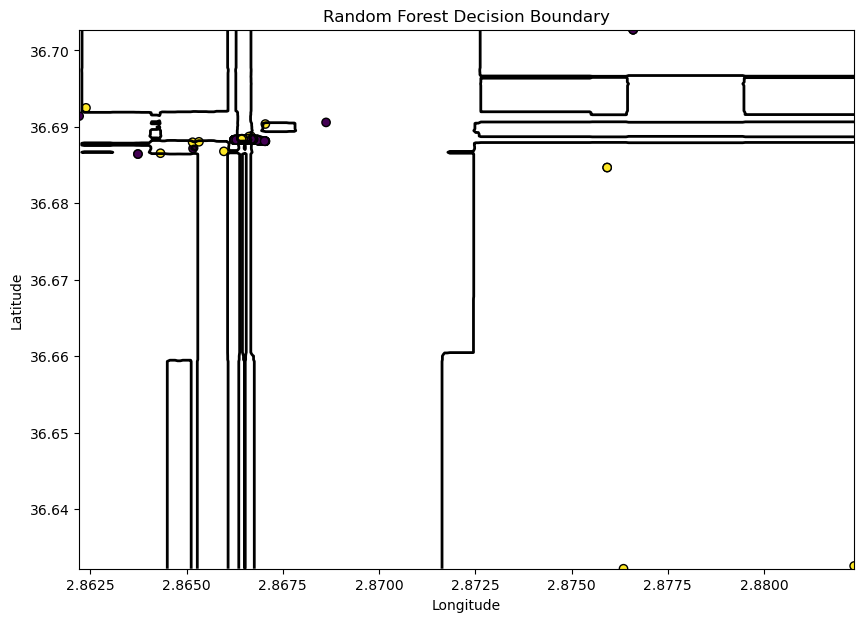

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Define bounds correctly
lat_min, lat_max = X['location_lat'].min(), X['location_lat'].max()
lng_min, lng_max = X['location_lng'].min(), X['location_lng'].max()

# IMPORTANT: meshgrid should be (lng, lat) for plotting
xx, yy = np.meshgrid(
    np.linspace(lng_min, lng_max, 300),   # x → longitude
    np.linspace(lat_min, lat_max, 300)    # y → latitude
)

# BUT model expects (lat, lng)
grid_points = pd.DataFrame(np.c_[yy.ravel(), xx.ravel()], columns=['location_lat', 'location_lng'])

Z = rf_model.predict_proba(grid_points)[:, 1]  # probability for class 6 (assuming 6 is positive)
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(10, 7))
plt.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)

# Plot actual points
plt.scatter(
    X['location_lng'],  # x
    X['location_lat'],  # y
    c=y,
    edgecolor='k'
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Random Forest Decision Boundary")
plt.show()

In [25]:
# Estimate bias and variance for Random Forest using multiple trainings
n_boot = 100
preds_rf = np.zeros((len(X_test), n_boot))

for i in range(n_boot):
    model_b = RandomForestClassifier(n_estimators=100, random_state=i)
    model_b.fit(X_train, y_train)
    preds_rf[:, i] = model_b.predict(X_test)

mean_preds_rf = preds_rf.mean(axis=1)
bias_rf = ((mean_preds_rf - y_test.values) ** 2).mean()
variance_rf = preds_rf.var(axis=1).mean()

print(f"Random Forest - Bias: {bias_rf:.4f}, Variance: {variance_rf:.4f}")

Random Forest - Bias: 0.0225, Variance: 0.0112


In [26]:
from sklearn.model_selection import cross_val_score

# Generalization error = 1 - cross-validated accuracy
cv = 5
lr_cv_scores = cross_val_score(LogisticRegression(), X, y, cv=cv, scoring='accuracy')
rf_cv_scores = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), X, y, cv=cv, scoring='accuracy')

lr_gen_error = 1 - lr_cv_scores.mean()
rf_gen_error = 1 - rf_cv_scores.mean()

print(f"Logistic Regression CV accuracy: {lr_cv_scores.mean():.4f} +/- {lr_cv_scores.std():.4f}")
print(f"Random Forest CV accuracy: {rf_cv_scores.mean():.4f} +/- {rf_cv_scores.std():.4f}")
print(f"Estimated generalization error (LR): {lr_gen_error:.4f}")
print(f"Estimated generalization error (RF): {rf_gen_error:.4f}")

Logistic Regression CV accuracy: 0.5510 +/- 0.0076
Random Forest CV accuracy: 0.9182 +/- 0.0205
Estimated generalization error (LR): 0.4490
Estimated generalization error (RF): 0.0818


Decision Tree accuracy: 0.9491525423728814
              precision    recall  f1-score   support

           5       0.93      0.96      0.94        26
           6       0.97      0.94      0.95        33

    accuracy                           0.95        59
   macro avg       0.95      0.95      0.95        59
weighted avg       0.95      0.95      0.95        59



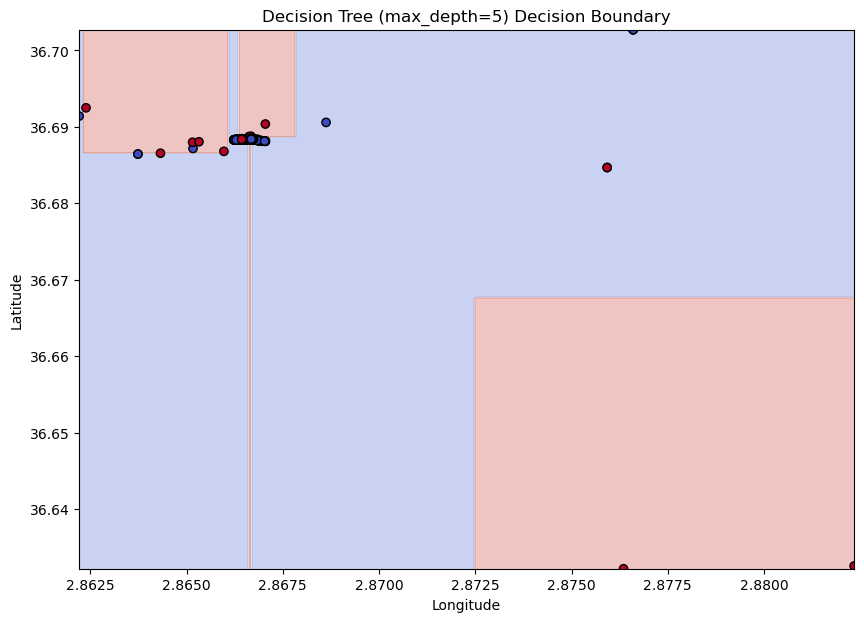

In [28]:
from sklearn.tree import DecisionTreeClassifier

# Train depth-limited decision tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
print("Decision Tree accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

# Plot decision boundary for decision tree
import numpy as np
import matplotlib.pyplot as plt

lat_min, lat_max = X['location_lat'].min(), X['location_lat'].max()
lng_min, lng_max = X['location_lng'].min(), X['location_lng'].max()

xx, yy = np.meshgrid(
    np.linspace(lng_min, lng_max, 300),
    np.linspace(lat_min, lat_max, 300)
)

grid_points = pd.DataFrame(np.c_[yy.ravel(), xx.ravel()], columns=['location_lat', 'location_lng'])
Z = dt_model.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X['location_lng'], X['location_lat'], c=y, edgecolor='k', cmap='coolwarm')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Decision Tree (max_depth=5) Decision Boundary')
plt.show()

KNN (k=5) accuracy: 0.9491525423728814
              precision    recall  f1-score   support

           5       0.93      0.96      0.94        26
           6       0.97      0.94      0.95        33

    accuracy                           0.95        59
   macro avg       0.95      0.95      0.95        59
weighted avg       0.95      0.95      0.95        59



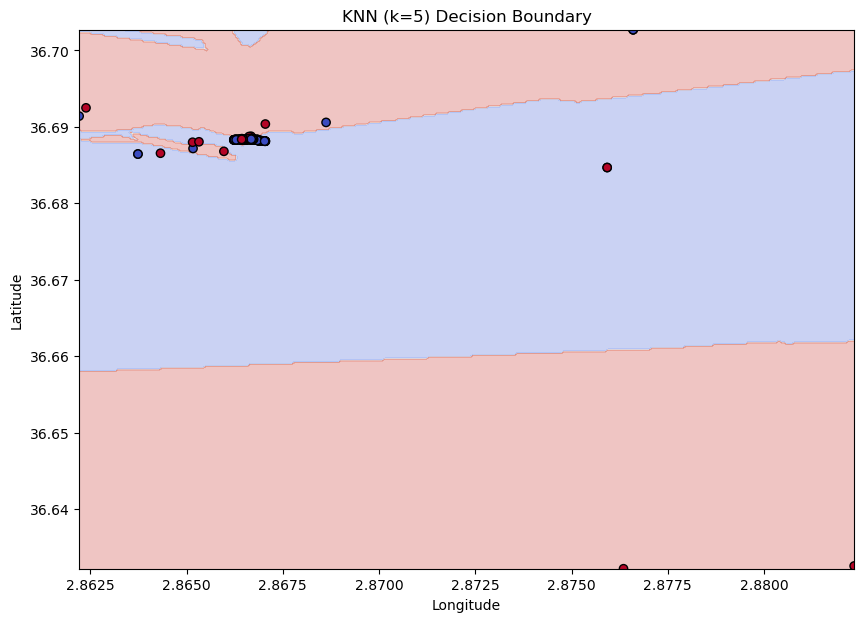

In [29]:
from sklearn.neighbors import KNeighborsClassifier

# Train KNN
eight = 5
knn_model = KNeighborsClassifier(n_neighbors=eight)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
print(f"KNN (k={eight}) accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

# Plot KNN decision boundary
lat_min, lat_max = X['location_lat'].min(), X['location_lat'].max()
lng_min, lng_max = X['location_lng'].min(), X['location_lng'].max()

xx, yy = np.meshgrid(
    np.linspace(lng_min, lng_max, 300),
    np.linspace(lat_min, lat_max, 300)
)

grid_points = pd.DataFrame(np.c_[yy.ravel(), xx.ravel()], columns=['location_lat', 'location_lng'])
Z = knn_model.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X['location_lng'], X['location_lat'], c=y, edgecolor='k', cmap='coolwarm')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'KNN (k={eight}) Decision Boundary')
plt.show()

# noise points detection

In [56]:
n_neighbors = 5

In [57]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# Initial dataset
current_df = df.copy()

# Ensure label exists
current_df['label'] = current_df['name'].str.extract(r'(\d+)').astype(int)
current_df = current_df[current_df['label'].isin([5, 6])]

history_sizes = []

for i in range(200):
    print(f"Iteration {i}, size = {len(current_df)}")

    X = current_df[['location_lat', 'location_lng']]
    y = current_df['label']

    # Train KNN
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X, y)

    # Predict on same data
    preds = knn.predict(X)

    # Keep only correctly classified
    correct_mask = (preds == y)
    filtered_df = current_df[correct_mask].copy()

    # Stop if too small
    if len(filtered_df) < 10:
        print("Stopped early (too few points)")
        break

    # Sample for next iteration (important)
    current_df = filtered_df.sample(frac=1.0, replace=False, random_state=i)

    history_sizes.append(len(current_df))

Iteration 0, size = 294
Iteration 1, size = 279
Iteration 2, size = 274
Iteration 3, size = 270
Iteration 4, size = 270
Iteration 5, size = 270
Iteration 6, size = 270
Iteration 7, size = 270
Iteration 8, size = 270
Iteration 9, size = 270
Iteration 10, size = 270
Iteration 11, size = 270
Iteration 12, size = 270
Iteration 13, size = 270
Iteration 14, size = 270
Iteration 15, size = 270
Iteration 16, size = 270
Iteration 17, size = 270
Iteration 18, size = 270
Iteration 19, size = 270
Iteration 20, size = 270
Iteration 21, size = 270
Iteration 22, size = 270
Iteration 23, size = 270
Iteration 24, size = 270
Iteration 25, size = 270
Iteration 26, size = 270
Iteration 27, size = 270
Iteration 28, size = 270
Iteration 29, size = 270
Iteration 30, size = 270
Iteration 31, size = 270
Iteration 32, size = 270
Iteration 33, size = 270
Iteration 34, size = 270
Iteration 35, size = 270
Iteration 36, size = 270
Iteration 37, size = 270
Iteration 38, size = 270
Iteration 39, size = 270
Iteration 

In [58]:
clean_df = current_df.copy()

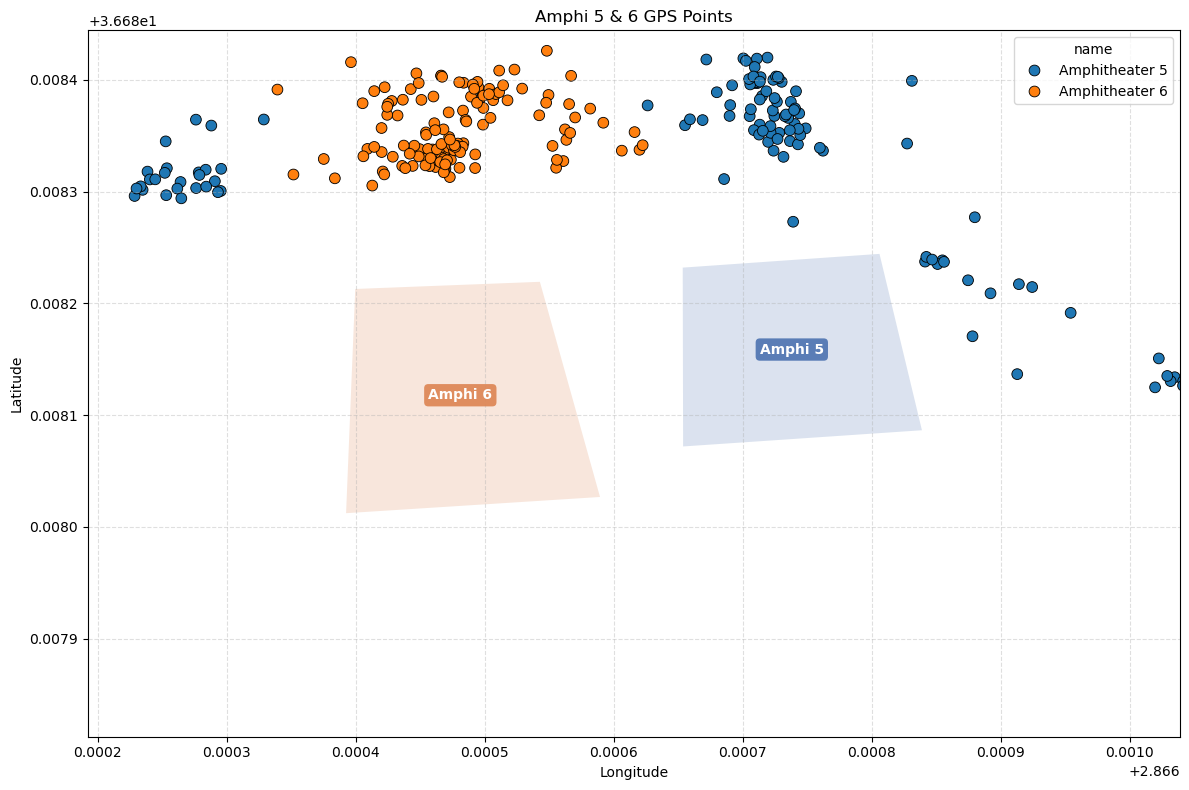

In [60]:


colors = ['#4C72B0', '#DD8452']
amphi_names = list(amphi_corners.keys())

fig, ax = plt.subplots(figsize=(12, 8))

# 1. Plot polygons
patches = []
for (name, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    poly = Polygon(xy, closed=True)
    patches.append(poly)

    # center label
    cx, cy = xy[:, 0].mean(), xy[:, 1].mean()
    ax.text(cx, cy, name, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.3', fc=color, ec='none', alpha=0.9))

collection = PatchCollection(patches, facecolors=colors, alpha=0.2)
ax.add_collection(collection)

# 2. Scatter points (your data)
sns.scatterplot(
    data=clean_df,
    x='location_lng',
    y='location_lat',
    hue='name',   # differentiate Amphi 5 vs 6
    s=60,
    edgecolor='black',
    ax=ax
)

# Formatting
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Amphi 5 & 6 GPS Points')

ax.grid(True, linestyle='--', alpha=0.4)

# auto limits
all_lats = [c[0] for corners in amphi_corners.values() for c in corners]
all_lons = [c[1] for corners in amphi_corners.values() for c in corners]

ax.set_xlim(min(all_lons) - 0.0002, max(all_lons) + 0.0002)
ax.set_ylim(min(all_lats) - 0.0002, max(all_lats) + 0.0002)

plt.tight_layout()
plt.show()

In [64]:
X = clean_df[['location_lat', 'location_lng']]
y = clean_df['label']

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

KNN (k=5) accuracy: 1.0
              precision    recall  f1-score   support

           5       1.00      1.00      1.00        25
           6       1.00      1.00      1.00        29

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



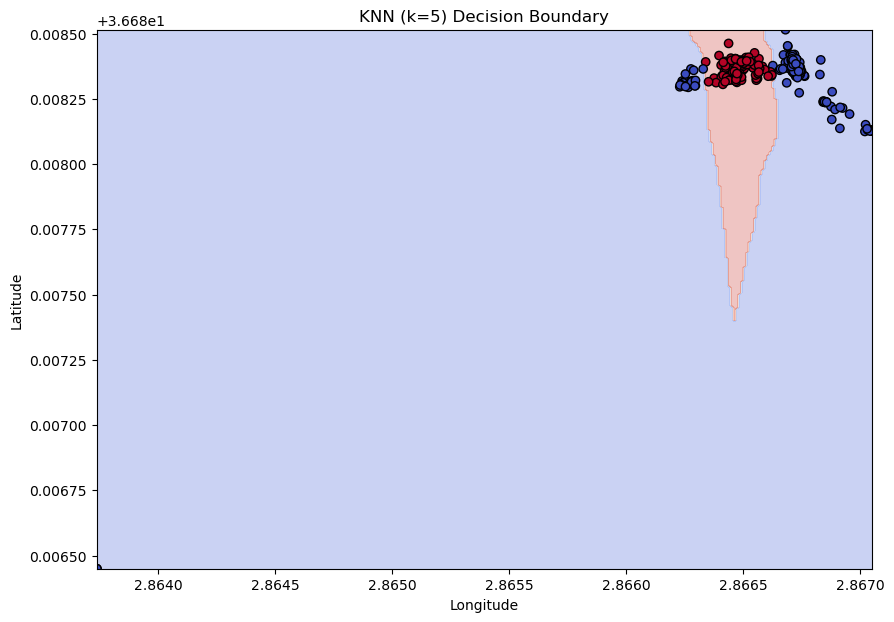

In [66]:
from sklearn.neighbors import KNeighborsClassifier

# Train KNN
eight = 5
knn_model = KNeighborsClassifier(n_neighbors=eight)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
print(f"KNN (k={eight}) accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

# Plot KNN decision boundary
lat_min, lat_max = X['location_lat'].min(), X['location_lat'].max()
lng_min, lng_max = X['location_lng'].min(), X['location_lng'].max()

xx, yy = np.meshgrid(
    np.linspace(lng_min, lng_max, 300),
    np.linspace(lat_min, lat_max, 300)
)

grid_points = pd.DataFrame(np.c_[yy.ravel(), xx.ravel()], columns=['location_lat', 'location_lng'])
Z = knn_model.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X['location_lng'], X['location_lat'], c=y, edgecolor='k', cmap='coolwarm')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'KNN (k={eight}) Decision Boundary')
plt.show()